In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


RUN_ROOT = Path(
    "/Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/"
    "global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes"
)

EXPORT_ROOT = RUN_ROOT / "saved_slow_mode_arrays" / "with_low_occupancy_cutoff"

print("RUN_ROOT exists:", RUN_ROOT.exists(), RUN_ROOT)
print("EXPORT_ROOT exists:", EXPORT_ROOT.exists(), EXPORT_ROOT)

species_names = sorted(p.name for p in EXPORT_ROOT.iterdir() if p.is_dir())

print(f"""
Directory check
---------------
Exists:       {EXPORT_ROOT.exists()}
Path:         {EXPORT_ROOT}
Species:      {len(species_names)}
""")

print("Species names:")
for species in species_names:
    print(f"  - {species}")

RUN_ROOT exists: True /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes
EXPORT_ROOT exists: True /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff

Directory check
---------------
Exists:       True
Path:         /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff
Species:      8

Species names:
  - Mus_caroli
  - Mus_musculus
  - Mus_spretus
  - Peromyscus_californicus
  - Peromyscus_gossypinus
  - Peromyscus_leucopus
  - Peromyscus_maniculatus
  - Peromyscus_polionotus


In [3]:
species_names = sorted(p.name for p in EXPORT_ROOT.iterdir() if p.is_dir())

def load_species_operator(species):
    species_dir = EXPORT_ROOT / species

    print("loading:", species_dir)

    return {
        "T": np.load(species_dir / "transfer_operator_macro.npy"),
        "evals": np.load(species_dir / "evals.npy"),
        "evecs": np.load(species_dir / "evecs_macro.npy"),
        "phi_macro_native": np.load(species_dir / "phi_macro_native.npy"),
        "phi_macro_shared": np.load(species_dir / "phi_macro_shared.npy"),
        "pi_macro": np.load(species_dir / "pi_macro.npy"),
        "chi_macro": np.load(species_dir / "chi_macro.npy"),
        "chi_macro_aligned": np.load(species_dir / "chi_macro_aligned.npy"),
        "pi_global": np.load(species_dir / "pi_global.npy"),
        "occupancy_global": np.load(species_dir / "occupancy_global.npy"),
        "chi_global": np.load(species_dir / "chi_global.npy"),
        "chi_global_aligned": np.load(species_dir / "chi_global_aligned.npy"),
        "phi_global_native": np.load(species_dir / "phi_global_native.npy"),
        "phi_global_shared": np.load(species_dir / "phi_global_shared.npy"),
        "arm_assignments_global_aligned": np.load(species_dir / "arm_assignments_global_aligned.npy"),
    }

ops = {species: load_species_operator(species) for species in species_names}

loading: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff/Mus_caroli
loading: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff/Mus_musculus
loading: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff/Mus_spretus
loading: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff/Peromyscus_californicus
loading: /Users/meganbishop/slowmodeevo/outputs/multispecies_slow_modes/global_clustering_modes/global_outputs/XY_EvenSampled_SlowModes/saved_slow_mode_arrays/with_low_occupancy_cutoff/Peromyscus_goss

In [4]:
ops['Mus_caroli'].keys()

dict_keys(['T', 'evals', 'evecs', 'phi_macro_native', 'phi_macro_shared', 'pi_macro', 'chi_macro', 'chi_macro_aligned', 'pi_global', 'occupancy_global', 'chi_global', 'chi_global_aligned', 'phi_global_native', 'phi_global_shared', 'arm_assignments_global_aligned'])

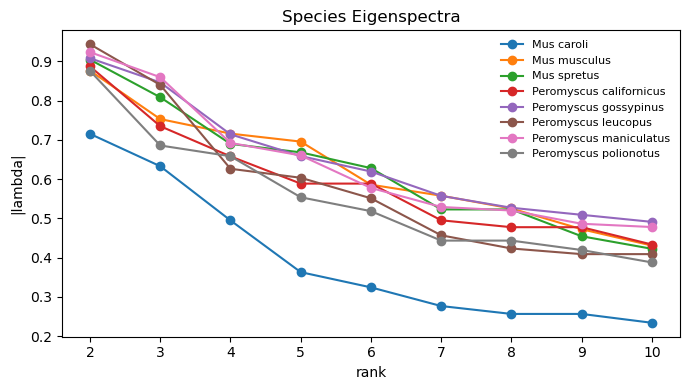

In [5]:
plt.figure(figsize=(7, 4))

for species in species_names:
    evals = ops[species]["evals"]
    ranks = np.arange(2, 2 + len(evals[:9]))

    plt.plot(
        ranks,
        np.abs(evals[:9]),
        marker="o",
        label=species.replace("_", " "),
    )

plt.xlabel("rank")
plt.ylabel("|lambda|")
plt.title("Species Eigenspectra")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
n_bins = 100
eps = 1e-12
# Free energy is always determined by occupancy probability from pi:
#     F(x) = -log P(x-bin)
# The reaction coordinate x changes across these four choices.
reaction_coordinates = [
    # {
    #     "coordinate": "shared_phi_2",
    #     "label": "shared phi_2",
    #     "array_key": "phi_global_shared",
    #     "column": 0,
    #     "description": "Shared-reference slow coordinate phi_2, lifted to global states.",
    # },
    # {
    #     "coordinate": "shared_phi_3",
    #     "label": "shared phi_3",
    #     "array_key": "phi_global_shared",
    #     "column": 1,
    #     "description": "Shared-reference slow coordinate phi_3, lifted to global states.",
    # },
    {
        "coordinate": "aligned_chi_1",
        "label": "aligned chi_1",
        "array_key": "chi_global_aligned",
        "column": 0,
        "description": "Hungarian-aligned relaxation-mode 1 membership.",
    },
    # {
    #     "coordinate": "aligned_chi_2",
    #     "label": "aligned chi_2",
    #     "array_key": "chi_global_aligned",
    #     "column": 1,
    #     "description": "Hungarian-aligned relaxation-mode 2 membership.",
    # },
]


def equal_state_bins_by_coordinate(x, n_bins):
    """Return index arrays for equal-number-of-state bins along coordinate x."""
    x = np.asarray(x, dtype=float)
    valid = np.flatnonzero(np.isfinite(x))
    ordered = valid[np.argsort(x[valid])]
    return [idx for idx in np.array_split(ordered, n_bins) if len(idx) > 0]


def free_energy_profile_for_coordinate(species, spec, n_bins=n_bins):
    pi = np.asarray(ops[species]["pi_global"], dtype=float)
    values = np.asarray(ops[species][spec["array_key"]], dtype=float)
    x = values[:, int(spec["column"])]

    rows = []
    for b, idx in enumerate(equal_state_bins_by_coordinate(x, n_bins), start=1):
        x_bin = x[idx]
        pi_bin = pi[idx]
        p_bin = float(pi_bin.sum())
        rows.append(
            {
                "species": species,
                "coordinate": spec["coordinate"],
                "coordinate_label": spec["label"],
                "coordinate_description": spec["description"],
                "bin": b,
                "x_min": float(np.min(x_bin)),
                "x_max": float(np.max(x_bin)),
                "x_center": float(0.5 * (np.min(x_bin) + np.max(x_bin))),
                "x_mean": float(np.mean(x_bin)),
                "x_std": float(np.std(x_bin)),
                "n_states": int(len(idx)),
                "p_bin": p_bin,
                "free_energy": float(-np.log(p_bin + eps)),
                "mean_state_pi": float(np.mean(pi_bin)),
            }
        )
    return rows


rows = []
for species in species_names:
    for spec in reaction_coordinates:
        rows.extend(free_energy_profile_for_coordinate(species, spec))

reaction_energy = pd.DataFrame(rows)
reaction_energy


,species,coordinate,coordinate_label,coordinate_description,bin,x_min,x_max,x_center,x_mean,x_std,n_states,p_bin,free_energy,mean_state_pi
0,Mus_caroli,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,1,0.000000,0.001279,0.000640,0.000422,0.000437,10,0.001410,6.564255,0.000141
1,Mus_caroli,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,2,0.001585,0.005409,0.003497,0.003601,0.001235,10,0.001133,6.782548,0.000113
2,Mus_caroli,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,3,0.006070,0.009851,0.007960,0.008265,0.001176,10,0.002012,6.208779,0.000201
3,Mus_caroli,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,4,0.010549,0.014386,0.012468,0.012763,0.001299,10,0.002465,6.005499,0.000247
4,Mus_caroli,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,5,0.014665,0.019066,0.016865,0.016943,0.001552,10,0.001588,6.445537,0.000159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,Peromyscus_polionotus,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,96,0.954875,0.958113,0.956494,0.956709,0.001139,10,0.013622,4.296076,0.001362
796,Peromyscus_polionotus,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,97,0.958118,0.960309,0.959213,0.959246,0.000774,10,0.011489,4.466345,0.001149
797,Peromyscus_polionotus,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,98,0.962240,0.969825,0.966032,0.965768,0.002089,10,0.014309,4.246869,0.001431
798,Peromyscus_polionotus,aligned_chi_1,aligned chi_1,Hungarian-aligned relaxation-mode 1 membership.,99,0.970020,0.976879,0.973450,0.972258,0.002177,10,0.010894,4.519551,0.001089


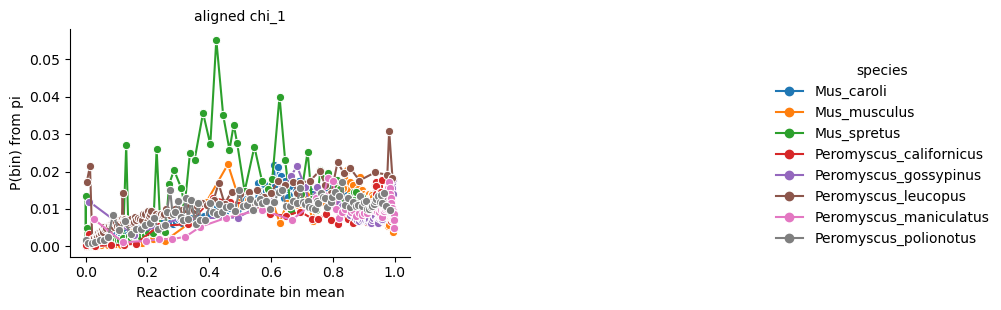

In [20]:
# Occupancy probability in each reaction-coordinate bin. This is the quantity
# that determines free energy: F = -log(P_bin).
g = sns.relplot(
    data=reaction_energy,
    x="x_mean",
    y="p_bin",
    hue="species",
    col="coordinate_label",
    col_wrap=2,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.25,
    facet_kws={"sharex": False, "sharey": False},
)

g.set_axis_labels("Reaction coordinate bin mean", "P(bin) from pi")
g.set_titles("{col_name}")
plt.show()


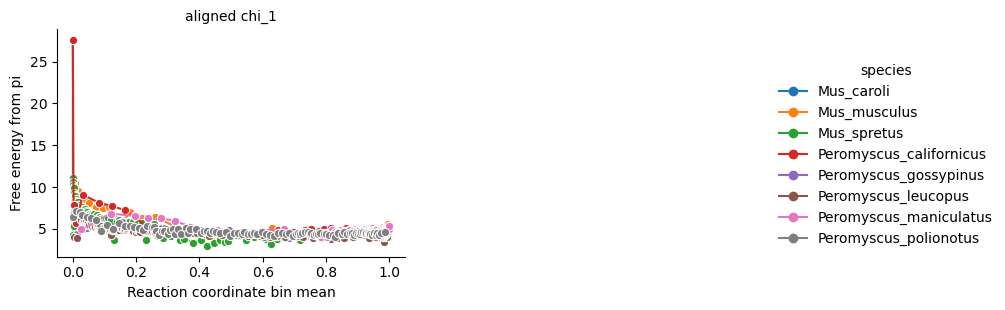

In [21]:
# Free-energy profiles along each reaction coordinate. Energy is always computed
# from pi, then shifted so each species-coordinate minimum is zero.
g = sns.relplot(
    data=reaction_energy,
    x="x_mean",
    y="free_energy",
    hue="species",
    col="coordinate_label",
    col_wrap=2,
    kind="line",
    marker="o",
    height=3.2,
    aspect=1.25,
    facet_kws={"sharex": False, "sharey": True},
)

g.set_axis_labels("Reaction coordinate bin mean", "Free energy from pi")
g.set_titles("{col_name}")
plt.show()


In [9]:
# Compact metrics for comparing energy-landscape shape across species.
summary_rows = []
for (species, coordinate), df in reaction_energy.groupby(["species", "coordinate"]):
    df = df.sort_values("x_mean")
    min_row = df.loc[df["free_energy"].idxmin()]
    max_row = df.loc[df["free_energy"].idxmax()]

    low = df.iloc[: max(1, len(df) // 5)]
    high = df.iloc[-max(1, len(df) // 5):]
    F_low = -np.log(low["p_bin"].sum() + eps)
    F_high = -np.log(high["p_bin"].sum() + eps)

    summary_rows.append(
        {
            "species": species,
            "coordinate": coordinate,
            "coordinate_label": df["coordinate_label"].iloc[0],
            "landscape_depth": float(df["free_energy"].max() - df["free_energy"].min()),
            "min_energy_x_mean": float(min_row["x_mean"]),
            "max_energy_x_mean": float(max_row["x_mean"]),
            "F_low_coordinate_quintile": float(F_low),
            "F_high_coordinate_quintile": float(F_high),
            "delta_F_high_minus_low": float(F_high - F_low),
            "p_low_coordinate_quintile": float(low["p_bin"].sum()),
            "p_high_coordinate_quintile": float(high["p_bin"].sum()),
        }
    )

reaction_energy_summary = pd.DataFrame(summary_rows)
reaction_energy_summary


,species,coordinate,coordinate_label,landscape_depth,min_energy_x_mean,max_energy_x_mean,F_low_coordinate_quintile,F_high_coordinate_quintile,delta_F_high_minus_low,p_low_coordinate_quintile,p_high_coordinate_quintile
0,Mus_caroli,aligned_chi_1,aligned chi_1,2.948283,0.609355,0.003601,2.880884,1.278677,-1.602207,0.056085,0.278405
1,Mus_musculus,aligned_chi_1,aligned chi_1,6.636119,0.460425,0.005514,2.231864,1.915749,-0.316115,0.107328,0.147232
2,Mus_spretus,aligned_chi_1,aligned chi_1,24.734435,0.422782,0.000000,3.833572,1.298740,-2.534832,0.021632,0.272875
3,Peromyscus_californicus,aligned_chi_1,aligned chi_1,23.592219,0.957778,0.000000,2.158160,1.677710,-0.480450,0.115538,0.186801
4,Peromyscus_gossypinus,aligned_chi_1,aligned chi_1,1.913754,0.684341,0.155108,1.442314,1.371131,-0.071182,0.236380,0.253820
5,Peromyscus_leucopus,aligned_chi_1,aligned chi_1,2.821891,0.982348,0.021155,2.182659,1.015883,-1.166775,0.112741,0.362082
6,Peromyscus_maniculatus,aligned_chi_1,aligned chi_1,2.826580,0.783619,0.120560,1.780442,1.765598,-0.014844,0.168564,0.171084
7,Peromyscus_polionotus,aligned_chi_1,aligned chi_1,3.088380,0.828787,0.009018,2.441871,1.457736,-0.984135,0.086998,0.232763


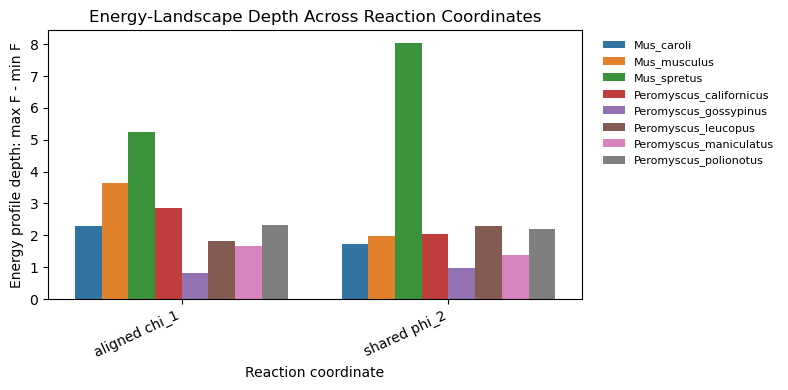

In [57]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=reaction_energy_summary,
    x="coordinate_label",
    y="landscape_depth",
    hue="species",
)
plt.xlabel("Reaction coordinate")
plt.ylabel("Energy profile depth: max F - min F")
plt.title("Energy-Landscape Depth Across Reaction Coordinates")
plt.xticks(rotation=25, ha="right")
plt.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Which reaction coordinate is most useful?

Free energy is computed the same way in every panel: `F(x) = -log P(x-bin)`, where `P(x-bin)` is the sum of `pi_global` for states in that bin. The only thing that changes is the reaction coordinate used to order/bin states.

`shared phi_2` and `shared phi_3` are the cleanest cross-species evolutionary comparisons because every species is projected onto the same pooled slow axes. If species differ in the location of the minimum, curve depth, or asymmetry along these shared coordinates, that suggests the slow dynamical landscape has shifted between species.

`aligned chi_1` and `aligned chi_4` are best for basin-depth questions. They ask whether moving from low membership to the core of an aligned relaxation mode becomes lower or higher energy, and whether that basin depth differs across species.


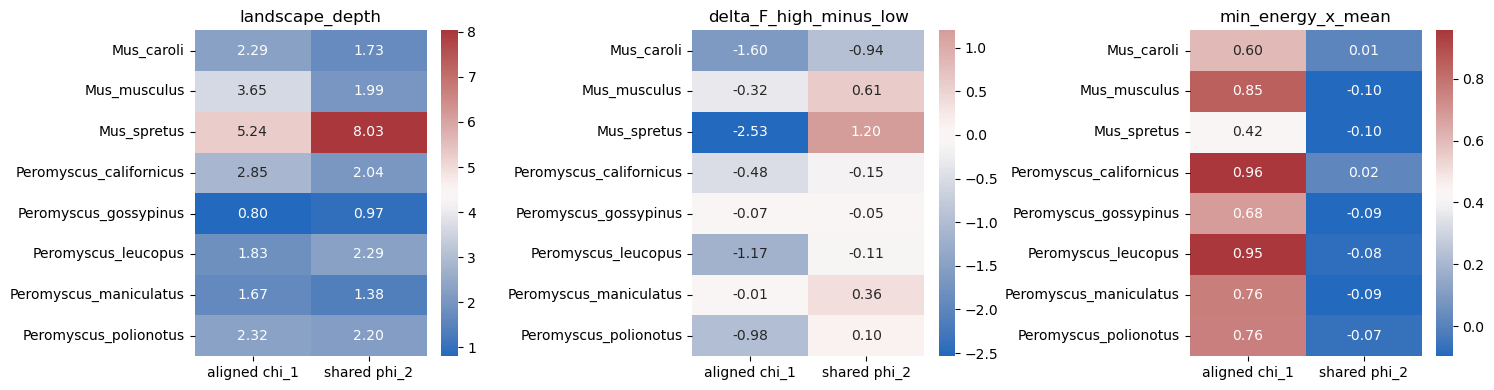

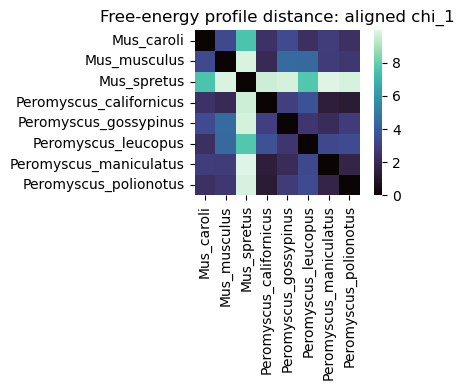

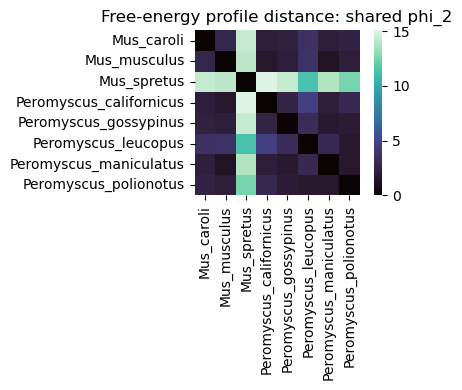

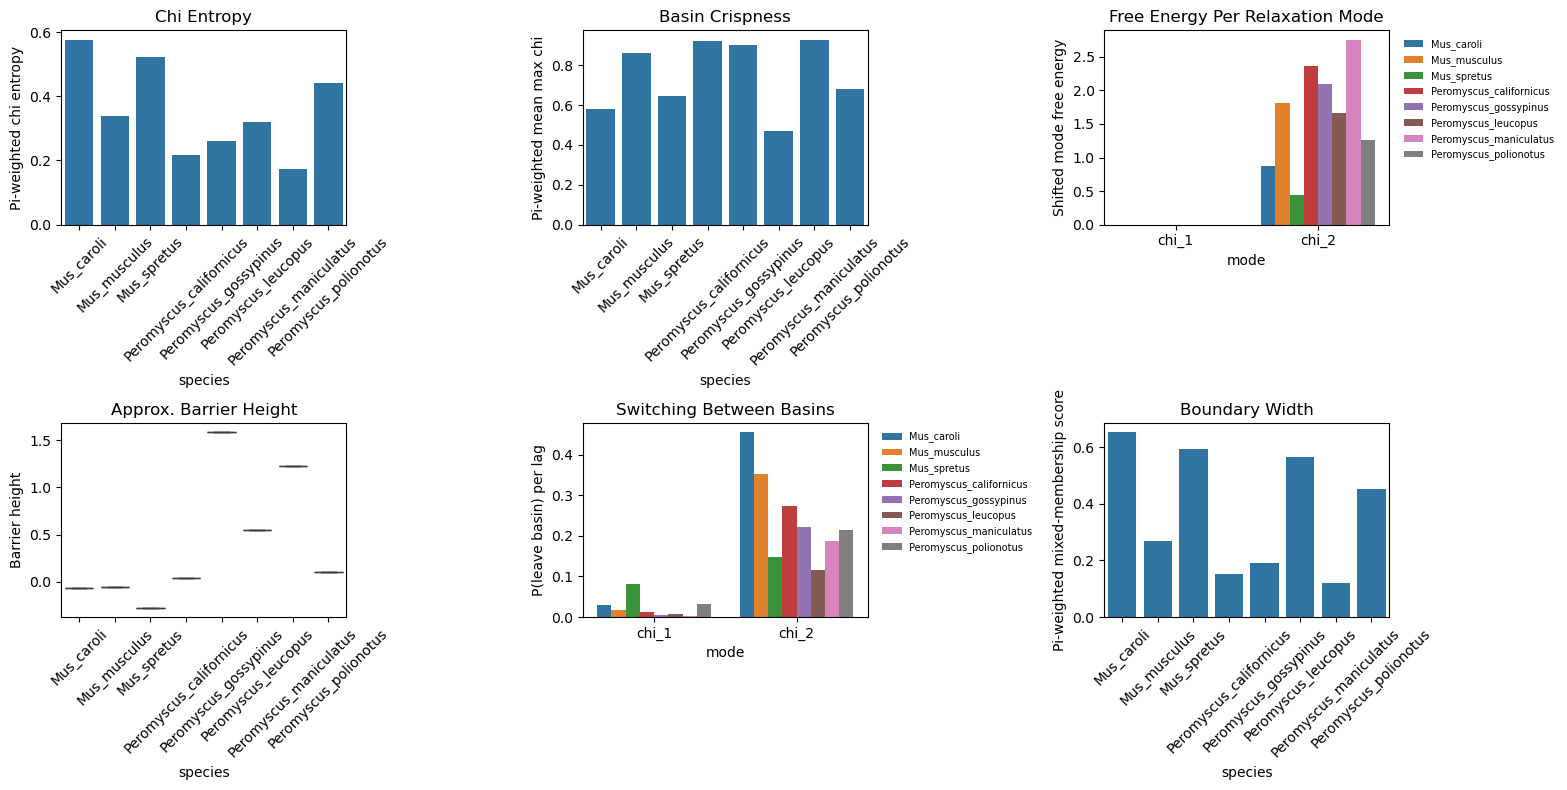

,species,chi_entropy_pi_weighted,mean_max_chi
0,Mus_caroli,0.576913,0.578116
1,Mus_musculus,0.338050,0.860508
2,Mus_spretus,0.521760,0.646187
3,Peromyscus_californicus,0.218160,0.921750
4,Peromyscus_gossypinus,0.261219,0.903069
5,Peromyscus_leucopus,0.320012,0.470443
6,Peromyscus_maniculatus,0.172605,0.929170
7,Peromyscus_polionotus,0.442888,0.682930


,species,mode,mode_index,mode_mass,mode_free_energy,mode_free_energy_shifted
0,Mus_caroli,chi_1,1,0.570864,0.560605,0.000000
1,Mus_caroli,chi_2,2,0.238708,1.432513,0.871908
2,Mus_musculus,chi_1,1,0.850518,0.161910,0.000000
3,Mus_musculus,chi_2,2,0.138970,1.973499,1.811589
4,Mus_spretus,chi_1,1,0.539862,0.616441,0.000000
5,Mus_spretus,chi_2,2,0.344940,1.064384,0.447942
6,Peromyscus_californicus,chi_1,1,0.910468,0.093796,0.000000
7,Peromyscus_californicus,chi_2,2,0.085631,2.457705,2.363909
8,Peromyscus_gossypinus,chi_1,1,0.887294,0.119579,0.000000
9,Peromyscus_gossypinus,chi_2,2,0.109751,2.209544,2.089965


,species,boundary_width,boundary_width_unweighted,boundary_state_fraction,boundary_probability_mass,boundary_cutoff
0,Mus_caroli,0.653339,0.713679,0.219,0.087425,0.1
1,Mus_musculus,0.268472,0.306481,0.102,0.042463,0.1
2,Mus_spretus,0.592428,0.720683,0.419,0.131604,0.1
3,Peromyscus_californicus,0.152599,0.215560,0.066,0.020372,0.1
4,Peromyscus_gossypinus,0.190907,0.191603,0.016,0.003027,0.1
5,Peromyscus_leucopus,0.565323,0.712641,0.248,0.107326,0.1
6,Peromyscus_maniculatus,0.121007,0.147677,0.013,0.002235,0.1
7,Peromyscus_polionotus,0.453925,0.513912,0.095,0.039124,0.1


,species,basin_a,basin_b,basin_pair,saddle_energy,barrier_height,n_boundary_states,boundary_cutoff
0,Mus_caroli,chi_1,chi_2,chi_1 - chi_2,6.281966,-0.064466,219,0.1
1,Mus_musculus,chi_1,chi_2,chi_1 - chi_2,5.508718,-0.050481,102,0.1
2,Mus_spretus,chi_1,chi_2,chi_1 - chi_2,4.609977,-0.278650,419,0.1
3,Peromyscus_californicus,chi_1,chi_2,chi_1 - chi_2,5.653233,0.037346,66,0.1
4,Peromyscus_gossypinus,chi_1,chi_2,chi_1 - chi_2,7.100378,1.589229,16,0.1
5,Peromyscus_leucopus,chi_1,chi_2,chi_1 - chi_2,5.893432,0.551480,248,0.1
6,Peromyscus_maniculatus,chi_1,chi_2,chi_1 - chi_2,6.491355,1.227451,13,0.1
7,Peromyscus_polionotus,chi_1,chi_2,chi_1 - chi_2,5.688504,0.107694,95,0.1


,species,mode,mode_index,basin_mass,p_leave_per_lag
0,Mus_caroli,chi_1,1,0.939883,0.029134
1,Mus_caroli,chi_2,2,0.060117,0.455489
2,Mus_musculus,chi_1,1,0.954897,0.016642
3,Mus_musculus,chi_2,2,0.045103,0.352329
4,Mus_spretus,chi_1,1,0.643701,0.081999
5,Mus_spretus,chi_2,2,0.356299,0.148142
6,Peromyscus_californicus,chi_1,1,0.958301,0.011942
7,Peromyscus_californicus,chi_2,2,0.041699,0.274451
8,Peromyscus_gossypinus,chi_1,1,0.974738,0.005729
9,Peromyscus_gossypinus,chi_2,2,0.025262,0.221040


,species,mode,energy_std,energy_range
0,Mus_caroli,global,0.577417,22.149737
1,Mus_caroli,chi_1,0.555921,22.149737
2,Mus_caroli,chi_2,0.666197,5.827068
3,Mus_musculus,global,0.624179,22.557844
4,Mus_musculus,chi_1,0.592581,22.071823
5,Mus_musculus,chi_2,0.820663,3.223349
6,Mus_spretus,global,1.303356,23.923312
7,Mus_spretus,chi_1,1.002818,22.742394
8,Mus_spretus,chi_2,0.546231,3.684111
9,Peromyscus_californicus,global,0.532440,22.082093


,coordinate_label,species_a,species_b,profile_distance
0,aligned chi_1,Mus_caroli,Mus_caroli,0.000000
1,aligned chi_1,Mus_caroli,Mus_musculus,3.305509
2,aligned chi_1,Mus_caroli,Mus_spretus,7.528005
3,aligned chi_1,Mus_caroli,Peromyscus_californicus,2.395177
4,aligned chi_1,Mus_caroli,Peromyscus_gossypinus,3.348041
...,...,...,...,...
123,shared phi_2,Peromyscus_polionotus,Peromyscus_californicus,2.939400
124,shared phi_2,Peromyscus_polionotus,Peromyscus_gossypinus,1.966195
125,shared phi_2,Peromyscus_polionotus,Peromyscus_leucopus,1.669886
126,shared phi_2,Peromyscus_polionotus,Peromyscus_maniculatus,1.602480


In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

eps = 1e-12

# Quick species-level diagnostics for the free-energy / relaxation-mode landscape.
# Global quantities use pi_global and chi_global_aligned, matching the existing
# free-energy reaction-coordinate plots. Switching uses the macro transition
# operator T, so it is computed from pi_macro and chi_macro_aligned.

# -----------------------------
# 1. Landscape metric heatmaps
# -----------------------------
landscape_metrics = [
    "landscape_depth",
    "delta_F_high_minus_low",
    "min_energy_x_mean",
]

fig, axes = plt.subplots(1, len(landscape_metrics), figsize=(5.0 * len(landscape_metrics), 4))
axes = np.atleast_1d(axes)

for ax, metric in zip(axes, landscape_metrics):
    heat = reaction_energy_summary.pivot(
        index="species",
        columns="coordinate_label",
        values=metric,
    )
    sns.heatmap(
        heat,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0 if "delta" in metric else None,
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


# -----------------------------
# 2. Chi entropy / basin crispness
# -----------------------------
entropy_rows = []

for species in species_names:
    pi = np.asarray(ops[species]["pi_global"], dtype=float)
    chi = np.asarray(ops[species]["chi_global_aligned"], dtype=float)

    state_entropy = -(chi * np.log(chi + eps)).sum(axis=1)
    max_chi = chi.max(axis=1)

    entropy_rows.append({
        "species": species,
        "chi_entropy_pi_weighted": np.average(state_entropy, weights=pi),
        "mean_max_chi": np.average(max_chi, weights=pi),
    })

chi_entropy_df = pd.DataFrame(entropy_rows)


# -----------------------------
# 3. Free energy per aligned relaxation mode
# P_mode_j = sum over states i of pi_i * chi_ij
# F_mode_j = -log(P_mode_j)
# -----------------------------
mode_energy_rows = []

for species in species_names:
    pi = np.asarray(ops[species]["pi_global"], dtype=float)
    chi = np.asarray(ops[species]["chi_global_aligned"], dtype=float)

    P_mode = chi.T @ pi
    F_mode = -np.log(P_mode + eps)
    F_mode_shifted = F_mode - F_mode.min()

    for j, (p, F, Fs) in enumerate(zip(P_mode, F_mode, F_mode_shifted), start=1):
        mode_energy_rows.append({
            "species": species,
            "mode": f"chi_{j}",
            "mode_index": j,
            "mode_mass": p,
            "mode_free_energy": F,
            "mode_free_energy_shifted": Fs,
        })

mode_energy_df = pd.DataFrame(mode_energy_rows)


# -----------------------------
# 4. Boundary width and approximate barrier heights
# Boundary width is a pi-weighted mixed-membership score.
# For two modes: 1 - abs(chi_1 - chi_2), where 1 is maximally mixed.
# For M > 2: 1 - (top chi - second-highest chi), where 1 is most ambiguous.
# -----------------------------
boundary_width_rows = []
barrier_rows = []
boundary_cutoff = 0.10

for species in species_names:
    pi = np.asarray(ops[species]["pi_global"], dtype=float)
    chi = np.asarray(ops[species]["chi_global_aligned"], dtype=float)

    E = -np.log(pi + eps)
    basin = chi.argmax(axis=1)
    M = chi.shape[1]
    top2_chi = np.sort(chi, axis=1)[:, -2:]
    boundary_score = 1.0 - (top2_chi[:, 1] - top2_chi[:, 0])

    boundary_width_rows.append({
        "species": species,
        "boundary_width": np.average(boundary_score, weights=pi),
        "boundary_width_unweighted": boundary_score.mean(),
        "boundary_state_fraction": np.mean(boundary_score >= 1.0 - boundary_cutoff),
        "boundary_probability_mass": pi[boundary_score >= 1.0 - boundary_cutoff].sum(),
        "boundary_cutoff": boundary_cutoff,
    })

    basin_min_E = np.array([
        E[basin == j].min() if np.any(basin == j) else np.nan
        for j in range(M)
    ])

    for j in range(M):
        for k in range(j + 1, M):
            if M == 2:
                chi_diff = np.abs(chi[:, j] - chi[:, k])
                boundary = chi_diff <= boundary_cutoff
            else:
                top2 = np.argsort(chi, axis=1)[:, -2:]
                boundary = (
                    ((top2[:, 0] == j) & (top2[:, 1] == k)) |
                    ((top2[:, 0] == k) & (top2[:, 1] == j))
                )

            if boundary.sum() == 0:
                continue

            saddle_E = np.min(E[boundary])
            barrier = saddle_E - max(basin_min_E[j], basin_min_E[k])

            barrier_rows.append({
                "species": species,
                "basin_a": f"chi_{j + 1}",
                "basin_b": f"chi_{k + 1}",
                "basin_pair": f"chi_{j + 1} - chi_{k + 1}",
                "saddle_energy": saddle_E,
                "barrier_height": barrier,
                "n_boundary_states": int(boundary.sum()),
                "boundary_cutoff": boundary_cutoff if M == 2 else np.nan,
            })

boundary_width_df = pd.DataFrame(boundary_width_rows)
barrier_df = pd.DataFrame(barrier_rows)


# -----------------------------
# 5. Switching probability from the macro transition operator
# p_leave_per_lag = probability of leaving each hard-assigned macro basin per lag.
# -----------------------------
switch_rows = []

for species in species_names:
    T = np.asarray(ops[species]["T"], dtype=float)
    pi = np.asarray(ops[species]["pi_macro"], dtype=float)
    chi = np.asarray(ops[species]["chi_macro_aligned"], dtype=float)

    basin = chi.argmax(axis=1)
    M = chi.shape[1]

    for j in range(M):
        mask = basin == j
        if mask.sum() == 0:
            continue

        basin_mass = pi[mask].sum()
        p_leave = np.sum(pi[mask] * T[np.ix_(mask, basin != j)].sum(axis=1))

        switch_rows.append({
            "species": species,
            "mode": f"chi_{j + 1}",
            "mode_index": j + 1,
            "basin_mass": basin_mass,
            "p_leave_per_lag": p_leave / (basin_mass + eps),
        })

switch_df = pd.DataFrame(switch_rows)


# -----------------------------
# 6. Landscape ruggedness
# Global and within-mode energy variation across global states.
# -----------------------------
rugged_rows = []

for species in species_names:
    pi = np.asarray(ops[species]["pi_global"], dtype=float)
    chi = np.asarray(ops[species]["chi_global_aligned"], dtype=float)

    E = -np.log(pi + eps)
    E_mean = np.average(E, weights=pi)

    rugged_rows.append({
        "species": species,
        "mode": "global",
        "energy_std": np.sqrt(np.average((E - E_mean) ** 2, weights=pi)),
        "energy_range": E.max() - E.min(),
    })

    basin = chi.argmax(axis=1)

    for j in range(chi.shape[1]):
        mask = basin == j
        if mask.sum() <= 1:
            continue

        Ej = E[mask]
        w = pi[mask] / pi[mask].sum()
        Ej_mean = np.average(Ej, weights=w)

        rugged_rows.append({
            "species": species,
            "mode": f"chi_{j + 1}",
            "energy_std": np.sqrt(np.average((Ej - Ej_mean) ** 2, weights=w)),
            "energy_range": Ej.max() - Ej.min(),
        })

rugged_df = pd.DataFrame(rugged_rows)


# -----------------------------
# 7. Pairwise species distances between shifted free-energy profiles
# -----------------------------
profile_distance_rows = []

for coord, dfc in reaction_energy.groupby("coordinate_label"):
    profiles = dfc.pivot(index="species", columns="bin", values="free_energy_shifted")
    species_order = profiles.index.to_list()
    D = np.linalg.norm(
        profiles.values[:, None, :] - profiles.values[None, :, :],
        axis=2,
    )

    for a, species_a in enumerate(species_order):
        for b, species_b in enumerate(species_order):
            profile_distance_rows.append({
                "coordinate_label": coord,
                "species_a": species_a,
                "species_b": species_b,
                "profile_distance": D[a, b],
            })

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        pd.DataFrame(D, index=species_order, columns=species_order),
        cmap="mako",
        square=True,
    )
    plt.title(f"Free-energy profile distance: {coord}")
    plt.tight_layout()
    plt.show()

profile_distance_df = pd.DataFrame(profile_distance_rows)


# -----------------------------
# Summary plots
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

sns.barplot(
    data=chi_entropy_df,
    x="species",
    y="chi_entropy_pi_weighted",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Chi Entropy")
axes[0, 0].set_ylabel("Pi-weighted chi entropy")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=chi_entropy_df,
    x="species",
    y="mean_max_chi",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Basin Crispness")
axes[0, 1].set_ylabel("Pi-weighted mean max chi")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.barplot(
    data=mode_energy_df,
    x="mode",
    y="mode_free_energy_shifted",
    hue="species",
    ax=axes[0, 2],
)
axes[0, 2].set_title("Free Energy Per Relaxation Mode")
axes[0, 2].set_ylabel("Shifted mode free energy")
axes[0, 2].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.boxplot(
    data=barrier_df,
    x="species",
    y="barrier_height",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Approx. Barrier Height")
axes[1, 0].set_ylabel("Barrier height")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=switch_df,
    x="mode",
    y="p_leave_per_lag",
    hue="species",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Switching Between Basins")
axes[1, 1].set_ylabel("P(leave basin) per lag")
axes[1, 1].legend(frameon=False, fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.barplot(
    data=boundary_width_df,
    x="species",
    y="boundary_width",
    ax=axes[1, 2],
)
axes[1, 2].set_title("Boundary Width")
axes[1, 2].set_ylabel("Pi-weighted mixed-membership score")
axes[1, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


# Reusable summary tables for follow-up inspection/export.
display(chi_entropy_df)
display(mode_energy_df)
display(boundary_width_df)
display(barrier_df)
display(switch_df)
display(rugged_df)
display(profile_distance_df)


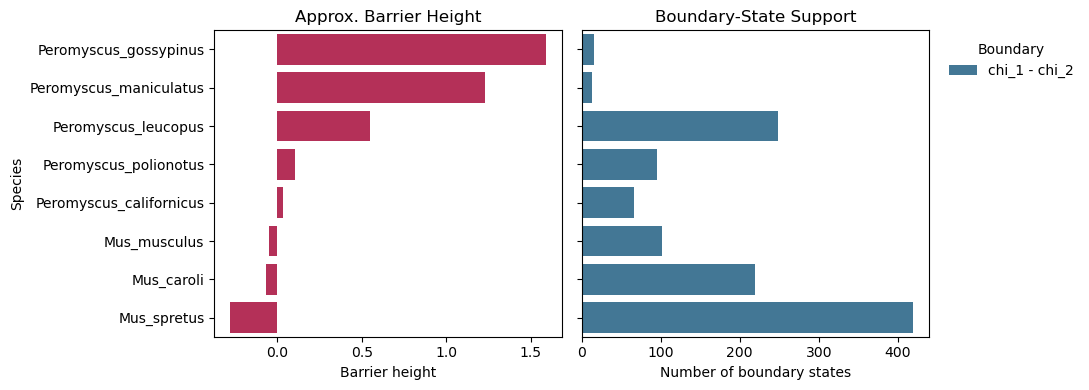

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

plot_df = barrier_df.sort_values("barrier_height", ascending=False)

sns.barplot(
    data=plot_df,
    x="barrier_height",
    y="species",
    hue="basin_pair",
    dodge=False,
    palette="rocket_r",
    ax=axes[0],
)
axes[0].set_title("Approx. Barrier Height")
axes[0].set_xlabel("Barrier height")
axes[0].set_ylabel("Species")
axes[0].legend_.remove()

sns.barplot(
    data=plot_df,
    x="n_boundary_states",
    y="species",
    hue="basin_pair",
    dodge=False,
    palette="mako",
    ax=axes[1],
)
axes[1].set_title("Boundary-State Support")
axes[1].set_xlabel("Number of boundary states")
axes[1].set_ylabel("")
axes[1].legend(title="Boundary", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [62]:
# Species differ in whether relaxation modes are separated by low-probability transition regions or connected through high-occupancy intermediate states. In some species, mixed-membership states have lower free energy than one or both hard-assigned basin cores, producing near-zero or negative apparent barrier heights. This suggests broader, more continuous relaxation-mode structure rather than sharply separated basins.

In [63]:
# That makes sense. A negative or near-zero “barrier” can be a signal that the landscape is not two deep basins with a sparse transition zone, but instead has a probability-rich intermediate region. If that pattern separates by genus, that’s genuinely interesting.
# I’d phrase the interpretation something like:
# Species differ in whether relaxation modes are separated by low-probability transition regions or connected through high-occupancy intermediate states. In some species, mixed-membership states have lower free energy than one or both hard-assigned basin cores, producing near-zero or negative apparent barrier heights. This suggests broader, more continuous relaxation-mode structure rather than sharply separated basins.

# For genus-level separation, the strongest plots to emphasize are probably:
# - boundary_width: broad mixed-membership region vs crisp basin separation
# - chi_entropy: soft/ambiguous mode assignment
# - barrier_height: whether the mixed region is high- or low-energy
# - p_leave_per_lag: whether that geometric softness corresponds to more switching
# If Peromyscus and Mus split cleanly across these, that’s a nice story: not just different basin depths, but different organization of behavioral relaxation dynamics.

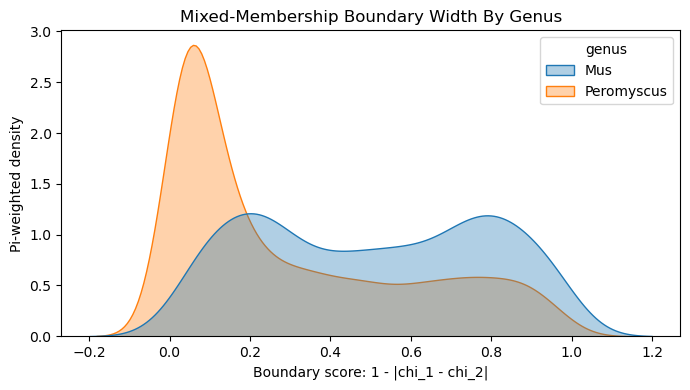

In [64]:
chi_diff_rows = []

for species in species_names:
    pi = ops[species]["pi_global"]
    chi = ops[species]["chi_global_aligned"]

    genus = species.split("_")[0]
    chi_diff = np.abs(chi[:, 0] - chi[:, 1])
    boundary_score = 1 - chi_diff

    for i in range(len(pi)):
        chi_diff_rows.append({
            "species": species,
            "genus": genus,
            "chi_diff": chi_diff[i],
            "boundary_score": boundary_score[i],
            "pi": pi[i],
            "energy": -np.log(pi[i] + 1e-12),
        })

chi_diff_df = pd.DataFrame(chi_diff_rows)

plt.figure(figsize=(7, 4))
sns.kdeplot(
    data=chi_diff_df,
    x="boundary_score",
    hue="genus",
    weights="pi",
    common_norm=False,
    fill=True,
    alpha=0.35,
)
plt.xlabel("Boundary score: 1 - |chi_1 - chi_2|")
plt.ylabel("Pi-weighted density")
plt.title("Mixed-Membership Boundary Width By Genus")
plt.tight_layout()
plt.show()

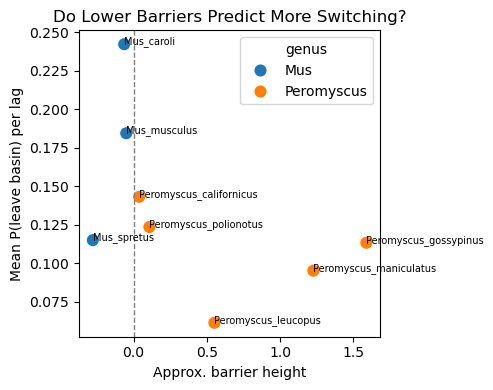

In [67]:
barrier_switch_df = barrier_df.merge(
    switch_df.groupby("species", as_index=False)["p_leave_per_lag"].mean(),
    on="species",
)
barrier_switch_df["genus"] = barrier_switch_df["species"].str.split("_").str[0]

plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=barrier_switch_df,
    x="barrier_height",
    y="p_leave_per_lag",
    hue="genus",
    s=90,
)

for _, r in barrier_switch_df.iterrows():
    plt.text(r["barrier_height"], r["p_leave_per_lag"], r["species"], fontsize=7)

plt.axvline(0, color="0.5", linestyle="--", linewidth=1)
plt.xlabel("Approx. barrier height")
plt.ylabel("Mean P(leave basin) per lag")
plt.title("Do Lower Barriers Predict More Switching?")
plt.tight_layout()
plt.show()

### 2D free-energy landscape over aligned chi 1 and chi 2

This view bins global states directly in the shared aligned `chi_global_aligned[:, 0:2]` plane and computes `F(chi1, chi2) = -log P(bin)` from `pi_global`. All species use the same chi axes and the same color scale, with a second row showing enrichment relative to the pooled cross-species landscape for easier between-species comparison.

In [ ]:
import pandas as pd
from scipy.ndimage import gaussian_filter
from matplotlib.colors import Normalize

CHI_LANDSCAPE_BINS = globals().get("CHI_LANDSCAPE_BINS", 70)
CHI_LANDSCAPE_SMOOTH_SIGMA = globals().get("CHI_LANDSCAPE_SMOOTH_SIGMA", 1.0)
CHI_LANDSCAPE_MIN_PROB = globals().get("CHI_LANDSCAPE_MIN_PROB", 1e-12)
CHI_LANDSCAPE_MAX_ENERGY_PERCENTILE = globals().get("CHI_LANDSCAPE_MAX_ENERGY_PERCENTILE", 98)
CHI_LANDSCAPE_ENRICHMENT_VMAX = globals().get("CHI_LANDSCAPE_ENRICHMENT_VMAX", 2.5)


def chi12_probability_grid(species, bins=CHI_LANDSCAPE_BINS, smooth_sigma=CHI_LANDSCAPE_SMOOTH_SIGMA):
    chi = np.asarray(ops[species]["chi_global_aligned"], dtype=float)
    if chi.shape[1] < 2:
        raise ValueError(f"{species} has only {chi.shape[1]} aligned chi columns; need at least chi_1 and chi_2")
    pi = np.asarray(ops[species]["pi_global"], dtype=float)
    valid = np.isfinite(chi[:, 0]) & np.isfinite(chi[:, 1]) & np.isfinite(pi) & (pi > 0)
    H, x_edges, y_edges = np.histogram2d(
        chi[valid, 0],
        chi[valid, 1],
        bins=bins,
        range=((0, 1), (0, 1)),
        weights=pi[valid],
    )
    H = gaussian_filter(H.T, sigma=smooth_sigma, mode="nearest")
    H = H / max(float(H.sum()), CHI_LANDSCAPE_MIN_PROB)
    return H, x_edges, y_edges


chi12_prob = {}
for species in species_names:
    chi12_prob[species], chi12_x_edges, chi12_y_edges = chi12_probability_grid(species)

pooled_chi12_prob = np.sum([chi12_prob[species] for species in species_names], axis=0)
pooled_chi12_prob = pooled_chi12_prob / max(float(pooled_chi12_prob.sum()), CHI_LANDSCAPE_MIN_PROB)

chi12_energy = {
    species: -np.log(chi12_prob[species] + CHI_LANDSCAPE_MIN_PROB)
    for species in species_names
}
chi12_energy = {
    species: grid - np.nanmin(grid[np.isfinite(grid)])
    for species, grid in chi12_energy.items()
}
energy_values = np.concatenate([grid[np.isfinite(grid)].ravel() for grid in chi12_energy.values()])
energy_vmax = float(np.nanpercentile(energy_values, CHI_LANDSCAPE_MAX_ENERGY_PERCENTILE))
energy_vmax = max(energy_vmax, 1.0)

chi12_enrichment = {
    species: np.log2((chi12_prob[species] + CHI_LANDSCAPE_MIN_PROB) / (pooled_chi12_prob + CHI_LANDSCAPE_MIN_PROB))
    for species in species_names
}

extent = [chi12_x_edges[0], chi12_x_edges[-1], chi12_y_edges[0], chi12_y_edges[-1]]
n_cols = min(4, len(species_names))
n_rows = int(np.ceil(len(species_names) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.8 * n_cols, 3.5 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)
for ax, species in zip(axes.flat, species_names):
    im = ax.imshow(
        chi12_energy[species],
        origin="lower",
        extent=extent,
        cmap="viridis_r",
        vmin=0,
        vmax=energy_vmax,
        interpolation="bilinear",
        aspect="equal",
    )
    contour = chi12_prob[species]
    positive = contour[contour > 0]
    if positive.size:
        levels = np.nanpercentile(positive, [70, 85, 95])
        levels = np.unique(levels[levels > 0])
        if levels.size:
            ax.contour(
                0.5 * (chi12_x_edges[:-1] + chi12_x_edges[1:]),
                0.5 * (chi12_y_edges[:-1] + chi12_y_edges[1:]),
                contour,
                levels=levels,
                colors="white",
                linewidths=0.6,
                alpha=0.8,
            )
    ax.plot([0, 1], [1, 0], color="white", linewidth=0.8, alpha=0.35)
    ax.set_title(species.replace("_", " "), fontsize=9)
    ax.tick_params(axis="both", labelsize=7, length=2.5, width=0.7)
for ax in axes.flat[len(species_names):]:
    ax.remove()
fig.supxlabel(r"aligned $\chi_1$")
fig.supylabel(r"aligned $\chi_2$")
fig.suptitle("Free-energy landscape in aligned chi1/chi2 space")
fig.colorbar(im, ax=[ax for ax in axes.flat[:len(species_names)]], location="right", fraction=0.025, pad=0.02, label="free energy above species minimum")
plt.show()

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.8 * n_cols, 3.5 * n_rows),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)
for ax, species in zip(axes.flat, species_names):
    im = ax.imshow(
        chi12_enrichment[species],
        origin="lower",
        extent=extent,
        cmap="coolwarm",
        vmin=-CHI_LANDSCAPE_ENRICHMENT_VMAX,
        vmax=CHI_LANDSCAPE_ENRICHMENT_VMAX,
        interpolation="bilinear",
        aspect="equal",
    )
    contour = chi12_prob[species]
    positive = contour[contour > 0]
    if positive.size:
        levels = np.nanpercentile(positive, [75, 90])
        levels = np.unique(levels[levels > 0])
        if levels.size:
            ax.contour(
                0.5 * (chi12_x_edges[:-1] + chi12_x_edges[1:]),
                0.5 * (chi12_y_edges[:-1] + chi12_y_edges[1:]),
                contour,
                levels=levels,
                colors="black",
                linewidths=0.55,
                alpha=0.65,
            )
    ax.plot([0, 1], [1, 0], color="black", linewidth=0.8, alpha=0.25)
    ax.set_title(species.replace("_", " "), fontsize=9)
    ax.tick_params(axis="both", labelsize=7, length=2.5, width=0.7)
for ax in axes.flat[len(species_names):]:
    ax.remove()
fig.supxlabel(r"aligned $\chi_1$")
fig.supylabel(r"aligned $\chi_2$")
fig.suptitle("Chi1/chi2 occupancy enrichment vs pooled species landscape")
fig.colorbar(im, ax=[ax for ax in axes.flat[:len(species_names)]], location="right", fraction=0.025, pad=0.02, label="log2 enrichment vs pooled")
plt.show()

chi12_summary_rows = []
for species in species_names:
    prob = chi12_prob[species]
    energy = chi12_energy[species]
    x_centers = 0.5 * (chi12_x_edges[:-1] + chi12_x_edges[1:])
    y_centers = 0.5 * (chi12_y_edges[:-1] + chi12_y_edges[1:])
    yy, xx = np.meshgrid(y_centers, x_centers, indexing="ij")
    min_idx = np.unravel_index(np.nanargmin(energy), energy.shape)
    chi12_summary_rows.append({
        "species": species,
        "genus": species.split("_")[0],
        "chi1_energy_min": float(xx[min_idx]),
        "chi2_energy_min": float(yy[min_idx]),
        "chi12_energy_depth_p98": float(np.nanpercentile(energy, 98) - np.nanmin(energy)),
        "mixed_chi_probability_mass": float(prob[(xx > 0.35) & (xx < 0.65) & (yy > 0.35) & (yy < 0.65)].sum()),
        "chi1_core_probability_mass": float(prob[(xx > 0.75) & (yy < 0.25)].sum()),
        "chi2_core_probability_mass": float(prob[(yy > 0.75) & (xx < 0.25)].sum()),
    })

chi12_landscape_summary = pd.DataFrame(chi12_summary_rows)
display(chi12_landscape_summary.sort_values(["genus", "species"]))
